In [10]:
from pathlib import Path
import sys
import time
import json
import joblib

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import src.models.svm as svm

In [2]:
DATA = PROJECT_ROOT / "data" / "processed"

X_train = pd.read_csv(
    DATA / "X_train_scaled.csv"
)

X_test = pd.read_csv(
    DATA / "X_test_scaled.csv"
)

y_train = pd.read_csv(
    DATA / "y_train.csv"
)["Label"]

y_test = pd.read_csv(
    DATA / "y_test.csv"
)["Label"]

label_encoder = joblib.load(
    DATA / "label_encoder.pkl"
)

print("=" * 60)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

print()

print("Number of Classes :", len(label_encoder.classes_))

print("=" * 60)

Training Samples : (72000, 20)
Testing Samples : (18000, 20)

Number of Classes : 9


In [3]:
start = time.time()

model = svm.train_svm(

    X_train,

    y_train

)

training_time = time.time() - start

print()

print("=" * 60)

print("Training Completed")

print()

print(f"Training Time : {training_time:.2f} seconds")

print("=" * 60)

c:\Users\HP\Desktop\RF Signal Processing\RF-Signal-Classification-using-ML\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
2026-07-05 21:02:43,418 | INFO | SVM training completed.



Training Completed

Training Time : 543.28 seconds


In [4]:
start = time.time()

metrics, predictions, report, cm = svm.evaluate_model(

    model,

    X_test,

    y_test

)

prediction_time = time.time() - start

print("=" * 60)

print(f"Accuracy  : {metrics['accuracy']:.4f}")

print(f"Precision : {metrics['precision']:.4f}")

print(f"Recall    : {metrics['recall']:.4f}")

print(f"F1 Score  : {metrics['f1']:.4f}")

print()

print(f"Prediction Time : {prediction_time:.2f} seconds")

print("=" * 60)

2026-07-05 21:03:27,095 | INFO | Accuracy : 0.9561


Accuracy  : 0.9561
Precision : 0.9561
Recall    : 0.9561
F1 Score  : 0.9560

Prediction Time : 43.66 seconds


In [5]:
print("=" * 60)

print("Classification Report")

print("=" * 60)

print()

print(

    report

)

Classification Report

              precision    recall  f1-score   support

           0     0.8586    0.8565    0.8576      2000
           1     0.9990    1.0000    0.9995      2000
           2     0.9490    0.9960    0.9719      2000
           3     0.9915    0.9885    0.9900      2000
           4     0.9555    0.9665    0.9610      2000
           5     0.9815    0.9795    0.9805      2000
           6     0.9970    0.9810    0.9889      2000
           7     0.9903    0.9705    0.9803      2000
           8     0.8828    0.8665    0.8746      2000

    accuracy                         0.9561     18000
   macro avg     0.9561    0.9561    0.9560     18000
weighted avg     0.9561    0.9561    0.9560     18000



In [6]:
cm_df = pd.DataFrame(

    cm,

    index=label_encoder.classes_,

    columns=label_encoder.classes_

)

print("=" * 60)

print("Confusion Matrix")

print("=" * 60)

cm_df

Confusion Matrix


,8PSK,AM-DSB,AM-SSB,BPSK,CPFSK,GFSK,PAM4,QAM64,QPSK
8PSK,1713,0,20,0,37,10,1,14,205
AM-DSB,0,2000,0,0,0,0,0,0,0
AM-SSB,1,0,1992,0,0,0,1,0,6
BPSK,1,0,19,1977,0,0,3,0,0
CPFSK,40,0,0,0,1933,16,0,0,11
GFSK,9,1,0,0,27,1959,0,0,4
PAM4,0,1,21,15,0,0,1962,0,1
QAM64,31,0,24,1,0,0,0,1941,3
QPSK,200,0,23,1,26,11,1,5,1733


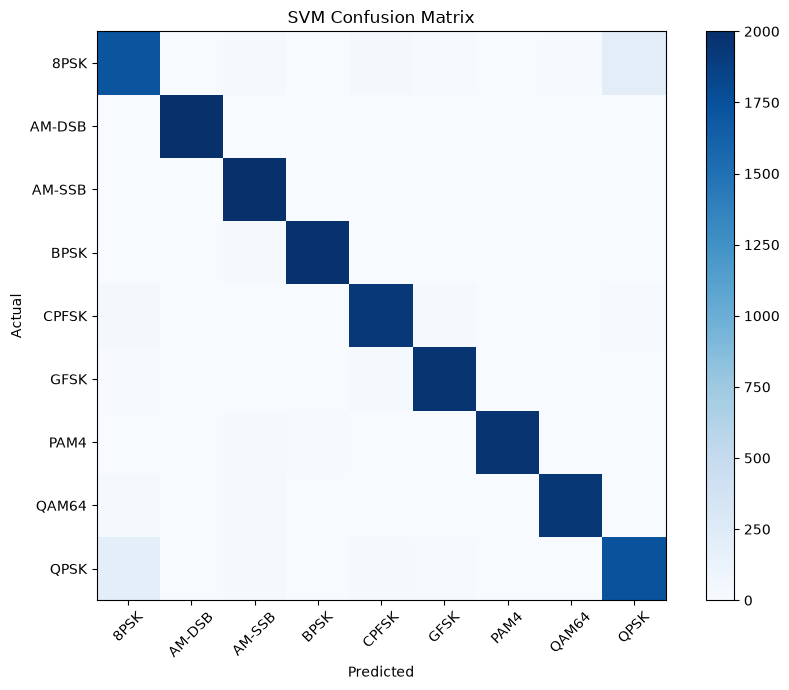

In [7]:
plt.figure(figsize=(9,7))

plt.imshow(cm, cmap="Blues")

plt.xticks(

    range(len(label_encoder.classes_)),

    label_encoder.classes_,

    rotation=45

)

plt.yticks(

    range(len(label_encoder.classes_)),

    label_encoder.classes_

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("SVM Confusion Matrix")

plt.colorbar()

plt.tight_layout()

plt.show()

In [8]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

per_class_df = pd.DataFrame({

    "Modulation": label_encoder.classes_,

    "Accuracy": per_class_accuracy

})

print("=" * 60)

print("Per-Class Accuracy")

print("=" * 60)

per_class_df

Per-Class Accuracy


,Modulation,Accuracy
0,8PSK,0.8565
1,AM-DSB,1.0000
2,AM-SSB,0.9960
3,BPSK,0.9885
4,CPFSK,0.9665
5,GFSK,0.9795
6,PAM4,0.9810
7,QAM64,0.9705
8,QPSK,0.8665


In [12]:
UNKNOWN_THRESHOLD = 0.75


def predict_signal(sample):

    prediction, confidence = svm.predict_unknown(

        model,

        sample,

        label_encoder,

        threshold=UNKNOWN_THRESHOLD

    )

    return prediction, confidence

In [13]:
sample = X_test.iloc[[0]]

prediction, confidence = predict_signal(sample)

print("=" * 60)

print("Prediction :", prediction)

print()

print("Confidence :", confidence)

print("=" * 60)

Prediction : PAM4

Confidence : 0.9938058007790603


In [14]:
MODEL_FOLDER = PROJECT_ROOT / "models"

MODEL_FOLDER.mkdir(

    parents=True,

    exist_ok=True

)

svm.save_model(

    model,

    MODEL_FOLDER / "svm.pkl"

)

svm.save_metadata(

    metrics,

    training_time,

    prediction_time,

    UNKNOWN_THRESHOLD,

    MODEL_FOLDER / "svm_metadata.json"

)

print()

print("SVM Model Saved Successfully")

2026-07-05 21:16:19,347 | INFO | Model saved at c:\Users\HP\Desktop\RF Signal Processing\RF-Signal-Classification-using-ML\models\svm.pkl
2026-07-05 21:16:19,351 | INFO | Metadata saved.



SVM Model Saved Successfully


In [15]:
REPORT_FOLDER = PROJECT_ROOT / "results" / "reports"

REPORT_FOLDER.mkdir(

    parents=True,

    exist_ok=True

)


per_class_df.to_csv(

    REPORT_FOLDER / "svm_per_class_accuracy.csv",

    index=False

)

cm_df.to_csv(

    REPORT_FOLDER / "svm_confusion_matrix.csv"

)

with open(

    REPORT_FOLDER / "svm_classification_report.txt",

    "w",

    encoding="utf-8"

) as file:

    file.write(report)

print()

print("Reports Saved Successfully")


Reports Saved Successfully


In [16]:
print("=" * 70)

print("Support Vector Machine Training Completed")

print("=" * 70)

print()

print(f"Accuracy           : {metrics['accuracy']:.4f}")

print(f"Precision          : {metrics['precision']:.4f}")

print(f"Recall             : {metrics['recall']:.4f}")

print(f"F1 Score           : {metrics['f1']:.4f}")

print()

print(f"Training Time      : {training_time:.2f} seconds")

print(f"Prediction Time    : {prediction_time:.2f} seconds")

print()

print(f"Kernel             : RBF")

print(f"C                  : 100")

print(f"Gamma              : 0.1")

print()

print(f"Unknown Threshold  : {UNKNOWN_THRESHOLD}")

print()

print("Model Saved At")

print(MODEL_FOLDER)

print()

print("Reports Saved At")

print(REPORT_FOLDER)

print()

print("=" * 70)

Support Vector Machine Training Completed

Accuracy           : 0.9561
Precision          : 0.9561
Recall             : 0.9561
F1 Score           : 0.9560

Training Time      : 543.28 seconds
Prediction Time    : 43.66 seconds

Kernel             : RBF
C                  : 100
Gamma              : 0.1

Unknown Threshold  : 0.75

Model Saved At
c:\Users\HP\Desktop\RF Signal Processing\RF-Signal-Classification-using-ML\models

Reports Saved At
c:\Users\HP\Desktop\RF Signal Processing\RF-Signal-Classification-using-ML\results\reports



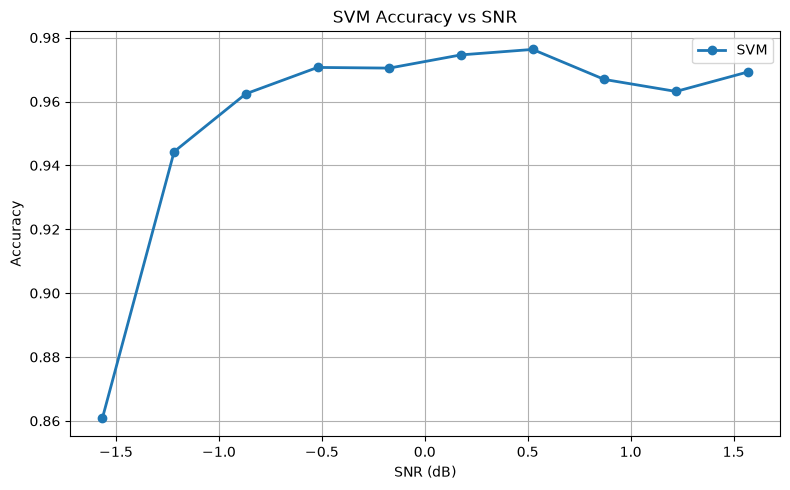

Saved : svm_accuracy_vs_snr.csv


,OriginalSNR,Accuracy
0,-1.565711,0.860875
1,-1.217435,0.944291
2,-0.869160,0.962410
3,-0.520884,0.970670
4,-0.172609,0.970457
5,0.175666,0.974596
6,0.523942,0.976306
7,0.872217,0.966910
8,1.220492,0.963149
9,1.568768,0.969239


In [17]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

# ==========================================================
# Predictions
# ==========================================================

svm_predictions = model.predict(X_test)

# ==========================================================
# Create Results DataFrame
# ==========================================================

snr_results = pd.DataFrame({

    "OriginalSNR": X_test["OriginalSNR"].values,

    "Actual": y_test.values,

    "Prediction": svm_predictions

})

# ==========================================================
# Accuracy vs SNR
# ==========================================================

accuracy_vs_snr = (

    snr_results

    .groupby("OriginalSNR")

    .apply(

        lambda x: accuracy_score(

            x["Actual"],

            x["Prediction"]

        ),

        include_groups=False

    )

    .reset_index(name="Accuracy")

    .sort_values("OriginalSNR")

)

# ==========================================================
# Save CSV
# ==========================================================

REPORT_DIR = PROJECT_ROOT / "results" / "reports"

REPORT_DIR.mkdir(

    parents=True,

    exist_ok=True

)

accuracy_vs_snr.to_csv(

    REPORT_DIR / "svm_accuracy_vs_snr.csv",

    index=False

)

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(

    accuracy_vs_snr["OriginalSNR"],

    accuracy_vs_snr["Accuracy"],

    marker="o",

    linewidth=2,

    label="SVM"

)

plt.xlabel("SNR (dB)")

plt.ylabel("Accuracy")

plt.title("SVM Accuracy vs SNR")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

# ==========================================================
# Display
# ==========================================================

print("="*60)

print("Saved : svm_accuracy_vs_snr.csv")

print("="*60)

accuracy_vs_snr